# Executive summary
- Novel method for combining four sets of disjoint tiles with better calibration than each set alone.
- Illustrate with simple example showcasing good performance and solving problems of original tiles (without retraining BLISS encoder).

# Example catalog
Consider original tiles + one overlapping layer where both height and width are shifted by 2 pixels.

In [53]:
from hydra import compose, initialize
from hydra.utils import instantiate
from omegaconf import OmegaConf
from einops import rearrange, repeat, reduce
import torch
import numpy as np

from case_studies.sdss_galaxies_vae.reconstruction import load_models, reconstruct_scene_at_coordinates

In [3]:
import os
os.environ["BLISS_HOME"] = "/home/dereklh/projects/bliss/"

In [4]:
with initialize(config_path="../sdss_galaxies_vae/config", job_name="overlap"):
    cfg = compose(config_name="config")   

In [5]:
simulated_dataset = instantiate(cfg.datasets.simulated)

In [23]:
batch_size=1
n_tiles_h=5
n_tiles_w=5
# tile_catalog = simulated_dataset.sample_prior(batch_size, n_tiles_h, n_tiles_w)
# tc2 = torch.load("catalog_with_stuff.pt")
# for (h, w) in ((0, 4), (3, 1)):
#     tile_catalog.n_sources[0, h, w] = 1
#     tile_catalog.locs[0, h, w] = tc2.locs[0, h, w]
#     for k, v in tc2.items():
#         tile_catalog[k][0, h, w] = v[0, h, w]
# torch.save(tile_catalog, "catalog.pt")
tile_catalog = torch.load("catalog.pt")

In [24]:
img, bg = simulated_dataset.simulate_image_from_catalog(tile_catalog)

In [25]:
import matplotlib.pyplot as plt

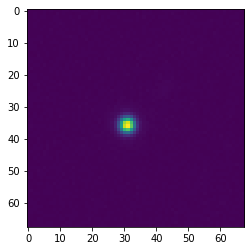

In [26]:
%matplotlib inline
plt.imshow(img[0, 0])

In [27]:
tile_catalog["galaxy_params"].shape

torch.Size([1, 5, 5, 1, 7])

In [28]:
tile_catalog.n_sources

tensor([[[0, 0, 0, 0, 1],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 1, 0, 0, 0],
         [0, 0, 0, 0, 0]]])

In [29]:
# load bliss
device = torch.device(cfg.reconstruct.device)
decoder, encoder, _ = load_models(cfg, device)
bp = 24
h, w = img.shape[2], img.shape[3]
# img_recon, tile_map_recon = reconstruct_scene_at_coordinates(encoder, decoder, img, bg, (bp, h-bp), (bp, w-bp))
img_recon, tile_map_recon = reconstruct_scene_at_coordinates(encoder, decoder, img, bg, (bp, h - bp), (bp, w - bp))

Encoding ptiles: 1it [00:00, 77.64it/s]


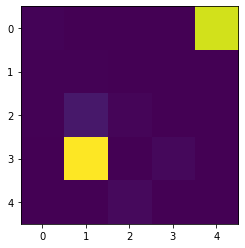

In [33]:
plt.imshow(tile_map_recon["n_source_log_probs"][0, :, :, 0, 0].exp().cpu())

What happens now when location is right at the edge of the tile corner?

In [34]:
## Force location to edge of tile
tile_catalog2 = tile_catalog.copy()
tile_catalog2.locs = tile_catalog.locs.clone()
tile_catalog2.locs[0, 3, 1, 0, :] = 0.999

In [35]:
img2, bg2 = simulated_dataset.simulate_image_from_catalog(tile_catalog2)

In [36]:
img_recon2, tile_map_recon2 = reconstruct_scene_at_coordinates(encoder, decoder, img2, bg2, (bp, h - bp), (bp, w - bp))

Encoding ptiles: 1it [00:00, 34.06it/s]


In [37]:
tile_map_recon2["n_source_log_probs"][0, :, :, 0, 0].exp()

tensor([[1.2460e-04, 7.0171e-05, 8.0281e-05, 1.4594e-04, 9.9345e-01],
        [1.4173e-03, 1.9973e-03, 3.7321e-04, 9.3870e-04, 1.6109e-03],
        [3.1301e-03, 3.2658e-03, 2.9761e-03, 2.4954e-03, 1.3581e-03],
        [2.7225e-03, 1.2757e-01, 1.7687e-01, 8.0137e-03, 1.9676e-04],
        [1.2870e-03, 1.2380e-01, 1.0012e-01, 7.8920e-03, 1.1599e-04]],
       device='cuda:0')

In [38]:
tile_map_recon2["n_source_log_probs"][0, 3:5, 1:3, 0, 0].exp().sum()

tensor(0.5284, device='cuda:0')

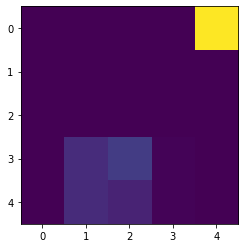

In [39]:
plt.imshow(tile_map_recon2["n_source_log_probs"][0, :, :, 0, 0].exp().cpu())

# Overlapping procedure
First, we shift the input image by two pixels in each direction and feed each to the encoder to get four different estimates.

In [40]:
def make_imgs_and_bgs():
    imgs = []
    bgs = []
    for w in (0, 2):
        for h in (0, 2):
            img_shifted = torch.zeros_like(img2)
            img_shifted[:, :, :(-h if h != 0 else None), :(-w if w != 0 else None)] = img2[:, :, h:, w:]
            bg_shifted = torch.zeros_like(bg2)
            bg_shifted[:, :, :(-h if h != 0 else None), :(-w if w != 0 else None)]  = bg2[:, :, h:, w:]
            if h > 0:
                img_shifted[:, :, -h:, :] = bg2[:, :, -h:, :]
                bg_shifted[:, :, -h:, :] = bg2[:, :, -h:, :]
            if w > 0:
                img_shifted[:, :, :, -w:] = bg2[:, :, :, -w:]
                bg_shifted[:, :, :, -w:] = bg2[:, :, :, -w:]
            if (h > 0) and (w > 0):
                img_shifted[:, :, -h:, -w:] = bg2[:, :, -h:, -w:]
                bg_shifted[:, :, -h:, -w:] = bg2[:, :, -h:, -w:]
            imgs.append(img_shifted)
            bgs.append(bg_shifted)
    return imgs, bgs
imgs, bgs = make_imgs_and_bgs()

In [41]:
tile_maps = []
for img, bg in zip(imgs, bgs):
    _, tile_map_shifted = reconstruct_scene_at_coordinates(encoder, decoder, img, bg, (bp, h - bp), (bp, w - bp))
    tile_maps.append(tile_map_shifted)

Encoding ptiles: 1it [00:00, 32.62it/s]
Encoding ptiles: 1it [00:00, 63.38it/s]
Encoding ptiles: 1it [00:00, 94.47it/s]
Encoding ptiles: 1it [00:00, 60.00it/s]


In [42]:
log_probs_all = torch.stack([t["n_source_log_probs"][0, :, :, 0, 0] for t in tile_maps], dim = -1)

In [43]:
prob_dbl = repeat(log_probs_all.exp(), "h w d -> (h h2) (w w2) d",h2=2, w2=2).cpu()
prob_super = torch.zeros(prob_dbl.shape[0] + 1, prob_dbl.shape[1] + 1, 4)

prob_super[:-1, :-1, 0] = prob_dbl[:, :, 0]
prob_super[1:, :-1, 1] = prob_dbl[:, :, 1]
prob_super[:-1, 1:, 2] = prob_dbl[:, :, 2]
prob_super[1:, 1:, 3] = prob_dbl[:, :, 3]

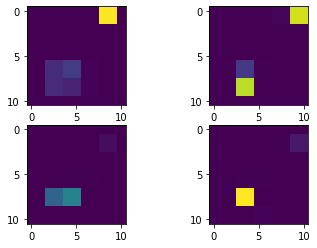

In [83]:
fig, axs = plt.subplots(2, 2)
for i in (0, 1):
    for j in (0, 1):
        axs[j, i].imshow(prob_super[:, :, 2*i + j], vmin=0, vmax=1)

- Object in top-right is not detected when tiles are shifted down by 2-pixels because they fall out of the boundary.
- Object in bottom-left is found in every tiling, but mass is either lost or gained

In [150]:
def plot_annotated_img(img, every_other_tile = True): 
    plt.imshow(img, vmin=0.0, vmax=1.0)
    for (j,i),label in np.ndenumerate(img):
        if ((i % 2 == 0) and (j % 2 == 0)) or (not every_other_tile):
            #l = f"{label:.2f}"
            l = int(label * 100)
            if l > 70:
                color = "b"
            else:
                color = "w"
            plt.text(i,j,l,ha='center',va='center', color=color)

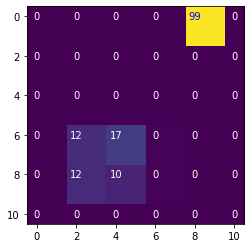

In [151]:
plot_annotated_img(prob_super[:, :, 0])

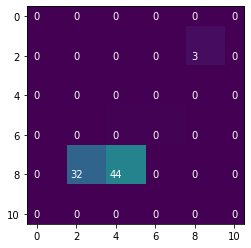

In [152]:
plot_annotated_img(prob_super[:, :, 1])

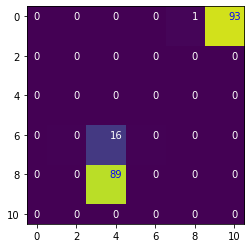

In [161]:
plot_annotated_img(prob_super[:, :, 2])

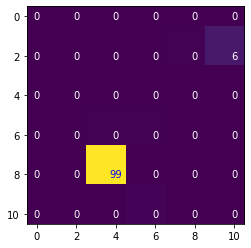

In [154]:
plot_annotated_img(prob_super[:, :, 3])

# Overlapping tiles variational distribution

## Variational Distribution
We parameterize the following variational distribution:
\begin{equation}
  \label{eq:vardist}
  \begin{split}
    A_{i} \sim \mathrm{Bernoulli}(\alpha_{i}) \\
    \ell_{i} \sim \mathcal N_{T_{i}} (\mu_{i}, \Sigma_{i})
  \end{split}
\end{equation}
where subscript $T_{i}$ means trucation to the tile $T_{i}$.
The variational posterior factorizes over tiles:
$$
q(\{A_i, \ell_i\}) = \prod_{i=1}^T \alpha_i^{A_i} q_i^\ell(\ell_i) ^{A_i} (1 - \alpha_i)^{1 - A_i}.
$$
Unlike in the previous, non-overlapping version, we do not assume that each tile $T_i$ is disjoint.
However, we assume that the tiles can be organized into **layers**, such that, within a layer $j$, each tile $T_{j, k}$ is disjoint with other tiles in layer $j$.
$$
q(\{A_{j, k}, \ell_{j, k}\}) = \prod_{j=1}^J \prod_{k} \alpha_j^{A_{j, k}} q_{j, k}^\ell(\ell_{j, k}) ^{A_{j, k}} (1 - \alpha_{j, k})^{1 - A_{j, k}}.
$$

We add an additional condition that two tiles with overlap cannot be both "on"
$$
A_i A_j = 0 ~ \text{if} ~ T_i \cap T_j \ne \varnothing
$$
As a result of this assumption, there is at most one object in the area of tile $T_i$. However, with overlap, it could be the case that $T_i$ did not **generate** that object.

Thus, our variational posterior is:
$$
\tilde q (\{\ell_{j, k}, A_{j, k}\}) = \frac{q (\{\ell_{j, k}, A_{j, k}\}) 1[A_i A_j = 0 ~ \text{if} ~ T_i \cap T_j \ne \varnothing]}{\int q (\{\ell_{j, k}, A_{j, k}\}) 1[A_i A_j = 0 ~ \text{if} ~ T_i \cap T_j \ne \varnothing] d \{\ell_{j, k}, A_{j, k}\}}
$$
Because of the denominator, this distribution is intractable.

The variational distribution factorizes along the tiles $k$ in layer $l$ conditional on the values in other layers.

$$
\begin{split}
\tilde q(\{A_{j, k}, \ell_{j, k}\}_{k} | \{A_{j^\prime, k}, \ell_{j^\prime, k}\}_{j^\prime \ne j, k}) \\
&\propto q (\{\ell_{j, k}, A_{j, k}\}) 1[A_i A_j = 0 ~ \text{if} ~ T_i \cap T_j \ne \varnothing] \\
&\propto \prod_{k} \alpha_j^{A_{j, k}} q_{j, k}^\ell(\ell_{j, k}) ^{A_{j, k}} (1 - \alpha_{j, k})^{1 - A_{j, k}} \prod_{j^\prime} \prod_{{k^\prime}} \alpha_{j^\prime}^{A_{{j^\prime}, {k^\prime}}} q_{{j^\prime}, {k^\prime}}^\ell(\ell_{{j^\prime}, {k^\prime}}) ^{A_{{j^\prime}, {k^\prime}}} (1 - \alpha_{{j^\prime}, {k^\prime}})^{1 - A_{{j^\prime}, {k^\prime}}} 1[A_{{j}, {k}} A_{j^\prime, k^\prime} = 0 ~ \text{if} ~ T_{j, k} \cap T_{j^\prime, k^\prime} \ne \varnothing]\\
&\propto \prod_{k} \alpha_j^{A_{j, k}} q_{j, k}^\ell(\ell_{j, k}) ^{A_{j, k}} (1 - \alpha_{j, k})^{1 - A_{j, k}} \prod_{j^\prime} \prod_{{k^\prime}} 1[A_{{j}, {k}} A_{j^\prime, k^\prime} = 0 ~ \text{if} ~ T_{j, k} \cap T_{j^\prime, k^\prime} \ne \varnothing] \\
&\equiv \prod_{k} \tilde q(A_{j, k}, \ell_{j, k} | \{A_{j^\prime, k}, \ell_{j^\prime, k}\}_{j^\prime \ne j, k})
\end{split}
$$

$$
\begin{split}
\tilde q(A_{j, k}, \ell_{j, k} | \{A_{j^\prime, k}, \ell_{j^\prime, k}\}_{j^\prime \ne j, k}) &\propto \alpha_j^{A_{j, k}} q_{j, k}^\ell(\ell_{j, k}) ^{A_{j, k}} (1 - \alpha_{j, k})^{1 - A_{j, k}} \prod_{j^\prime} \prod_{{k^\prime}} 1[A_{{j}, {k}} A_{j^\prime, k^\prime} = 0 ~ \text{if} ~ T_{j, k} \cap T_{j^\prime, k^\prime} \ne \varnothing]\\
&= \begin{cases}
\alpha_{j, k}^{A_{j, k}} q_{j, k}^\ell(\ell_{j, k}) ^{A_{j, k}} (1 - \alpha_{j, k})^{1 - A_{j, k}} ~ \text{if no overlapping tiles are on} \\
1[A_{j, k} = 0] ~ \text{otherwise} \\
\end{cases}
\end{split}
$$

Thus, conditioned on the tiles in other layers, the distributions of the $A_{i, j}$ are independent and Bernoulli.
The probability is either equal to $\alpha_{j, k}$ or $0$; we refer to this value as $\alpha^\star_{j, k}$.

Since the conditional distributions are tractable, we can utilize Gibbs sampling to target the joint distribution of each tile.
1. Start at $A_i = 0$ everywhere.
1. For each iteration
  1. For each layer of disjoint tiles $k$
    1. For each tile $A_{i, k}$ (parallelizable)
      1. Evaluate whether any tiles overlapping with $A_{i, k}$ are on.
      1. Sample $A_{i, k} = 1$ with probability $\alpha_i^\star = \alpha_i 1[A_{overlap(i) = 0}]$.

- In this variational distribution, $\alpha_{j, k}$ is the probability that $A_{j, k} = 1$ given no overlapping tiles are on. 
- This suggests that the original, non-overlapping training procedure can be used here; that is effectively learning the distribution of tiles with no overlap anywhere.
- Hence, for the remainder of this demo, we will utilize the same BLISS encoder as for non-overlapping tiles.
- However, future work will be understanding under what conditions this works.

### Original FAVI objective for tile (j, k) (i.e. no overlapping tiles)
$$
\int \log q (A_{j, k}, \ell_{j, k} | X_{j, k}) dP(X_{j, k} | A_{j, k}, \ell_{j, k}) dP(\ell_{j, k} | A_{j, k}) dP(A_{j, k})
$$


### New conditional FAVI objective
Let $\tilde q, \tilde P$ distinguish the new variational distribution and new generative model with the overlapping tiles where overlapping tiles can not be on at the same time.
$$
\tilde P(\{A_{j, k}\}) = (\prod_{j=1}^4 \prod_k \lambda^{A_{j, k}} (1 - \lambda)^{1 - A_{j, k}}) 1[A_{j,k} A_{j^\prime, k^\prime} = 0 ~ \text{for} ~ (j^\prime, k^\prime) \in \text{overlap}(j, k)]
$$
Like in the variational distribution, $\tilde P(A_{j, k} | \{A_{\text{overlap}(j,k)} = 0\}) = \lambda^{A_{j, k}} (1 - \lambda)^{1 - A_{j, k}}$.
$$
\int \log \tilde q (A_{j, k}, \ell_{j, k} ; X_{j, k} | \{A_{\text{overlap}(j,k)= 0}\}) d \tilde P(X_{j, k} | A_{j, k}, \ell_{j, k}, \{A_{\text{overlap}(j,k)} = 0\}) d \tilde P(\ell_{j, k} | A_{j, k}) d \tilde P(A_{j, k} | \{A_{\text{overlap}(j,k)} = 0\})
$$
The following are true:
- $\tilde P(A_{j, k} | \{A_{\text{overlap}(j,k)} = 0\}) = P(A_{j, k}) = \lambda^{A_{j,k}}(1-\lambda)^{1 - A_{j,k}}$
- $\tilde P(\ell_{j, k} | A_{j, k}) = P(\ell_{j, k} | A_{j, k}) = \frac 1 h^2 1 [\ell_{j, k} \in T_{j, k}]$ (uniform)
- $\tilde q (A_{j, k}, \ell_{j, k} | X_{j, k} , \{A_{\text{overlap}(j,k)= 0}\}) = q (A_{j, k}, \ell_{j, k} | X_{j, k})$ assuming the same encoder is used to output $\alpha_{j, k}, \mu_{j, k}, \sigma_{j, k}$

Thus, we can rewrite the conditional objective as:
$$
\int \log q (A_{j, k}, \ell_{j, k} | X_{j, k}) d \tilde P(X_{j, k} | A_{j, k}, \ell_{j, k}, \{A_{\text{overlap}(j,k)} = 0\}) d P(\ell_{j, k} | A_{j, k}) d P(A_{j, k})
$$
The only remaining difference is the generation of the padded tile $X_{j, k}$.

#### Assumption 1
$$
\tilde P(X_{j, k} | A_{j, k}, \ell_{j, k}, \{A_{\text{overlap}(j,k)} = 0\}) \approx P(X_{j, k} | A_{j, k}, \ell_{j, k}) = \tilde P(X_{j, k} | A_{j, k}, \ell_{j, k}, \{A_{j^\prime,k} = 0\}_{j^\prime \ne j})
$$
This assumption states that the distribution of padded tiles conditional on no overlapping tiles with $T_{j, k}$ being on is the same as the original generative model, which has no overlapping tiles at all.

With Assumption 1, we can use our existing BLISS encoder without re-training, and utilize the new Gibbs inference procedure to see if the end result improves.

In [75]:
def get_comparison_indices(offset):
    if offset == 1:
        return 1, None, 0, -1
    elif offset == -1:
        return 0, -1, 1, None
    raise ValueError()

In [76]:
def has_no_neighbor(offset_h, offset_w, tiles_other):
    no_neighbors = (~tiles_other[:, :])
    if offset_h != 0:
        ah,bh,ch,dh = get_comparison_indices(offset_h)
        no_neighbors[ah:bh, :] &= (~tiles_other[ch:dh, :])
    if offset_w != 0:
        aw,bw,cw,dw = get_comparison_indices(offset_w)
        no_neighbors[:, aw:bw] &= (~tiles_other[:, cw:dw])
    if ((offset_h != 0) and (offset_w != 0)):
        no_neighbors[ah:bh, aw:bw] &= (~tiles_other[ch:dh, cw:dw])
    return no_neighbors

In [77]:
def has_no_neighbor_all_four(idx, tiles, offsets):
    no_neighbors = torch.ones_like(tiles[:, :, idx])
    own_offset = offsets[idx]
    for other, (offset_h, offset_w) in enumerate(offsets):
        if other != idx:
            offset_h = offset_h - own_offset[0]
            offset_w = offset_w - own_offset[1]
            n = has_no_neighbor(offset_h, offset_w, tiles[:, :, other])
            no_neighbors *= n
    return no_neighbors

In [78]:
def sample_tile_marginals_from_cats(tile_maps, offsets, n_iter=1_000):
    log_probs = torch.stack([t["n_source_log_probs"][0, :, :, 0, 0] for t in tile_maps], dim = -1)
    tiles = torch.zeros(n_iter, *log_probs.shape, dtype=bool, device=log_probs.device)
    for i in range(n_iter):
        for idx, offset in enumerate(offsets):
            i_prev = 0 if i==0 else i-1
            no_neighbors = has_no_neighbor_all_four(idx, tiles[i_prev], offsets)
            tiles[i, :, :, idx] = torch.rand_like(tiles[i, :, :, idx], dtype=float).log() <= (log_probs[:, :, idx] + no_neighbors.log())
    return tiles.float().mean(0), tiles

In [79]:
xx_offsets = [
    (0,0),
    (1,0),
    (0,1),
    (1,1),
]
xx, tile_samples = sample_tile_marginals_from_cats(tile_maps, xx_offsets, n_iter=10_000)

In [206]:
def calc_marginals_from_cats(tile_maps, offsets, n_iter=10):
    log_cond_probs = torch.stack([t["n_source_log_probs"][0, :, :, 0, 0] for t in tile_maps], dim = -1)
    cond_probs = log_cond_probs.exp()
    probs = torch.ones(*cond_probs.shape, dtype=float, device=cond_probs.device) * 0.1
    ol = []
    for i in range(n_iter):
        for idx, offset in enumerate(offsets):
            overlapping_probs = get_overlapping_probs(idx, probs, offsets)
            probs[:, :, idx] = (1 - overlapping_probs) * cond_probs[:, :, idx]
            ol.insert(idx, overlapping_probs)
    return probs, ol

def get_overlapping_probs(idx, probs, offsets):
    own_offset = offsets[idx]
    overlapping_probs = torch.zeros_like(probs[:, :, idx])
    for other, (offset_h, offset_w) in enumerate(offsets):
        if other != idx:
            offset_h = offset_h - own_offset[0]
            offset_w = offset_w - own_offset[1]
            n = sum_up_overlaps(offset_h, offset_w, probs[:, :, other])
            overlapping_probs += n
    return overlapping_probs
            
def sum_up_overlaps(offset_h, offset_w, probs_other):
    overlaps = probs_other.clone()
    if offset_h != 0:
        ah,bh,ch,dh = get_comparison_indices(offset_h)
        overlaps[ah:bh, :] += probs_other[ch:dh, :]
    if offset_w != 0:
        aw,bw,cw,dw = get_comparison_indices(offset_w)
        overlaps[:, aw:bw] += probs_other[:, cw:dw]
    if ((offset_h != 0) and (offset_w != 0)):
        overlaps[ah:bh, aw:bw] += probs_other[ch:dh, cw:dw]
    return probs_other

In [207]:
xx2, ol = calc_marginals_from_cats(tile_maps, xx_offsets, n_iter=1000)

In [221]:
ol[-1]

tensor([[4.2582e-04, 8.7534e-04, 6.3599e-04, 1.2800e-02, 8.8644e-01],
        [3.8338e-03, 3.0691e-03, 1.6979e-03, 4.8700e-03, 4.0361e-03],
        [6.7050e-03, 6.2057e-03, 1.0743e-02, 8.1505e-03, 2.5854e-03],
        [8.1975e-03, 4.1562e-01, 4.2950e-01, 8.9258e-03, 9.0924e-04],
        [2.7193e-03, 8.1594e-01, 7.1704e-02, 1.0542e-02, 7.1025e-04]],
       device='cuda:0', dtype=torch.float64)

In [211]:
xx2[:, :, -2]

tensor([[1.5116e-04, 5.8316e-04, 2.2173e-04, 1.2812e-02, 8.2918e-02],
        [2.6000e-03, 1.0394e-03, 8.3294e-04, 3.4122e-03, 2.5212e-03],
        [3.5901e-03, 2.0257e-03, 2.9830e-03, 1.5234e-03, 1.2484e-03],
        [5.8771e-03, 7.1753e-05, 3.6978e-03, 1.9751e-03, 3.5319e-04],
        [1.4443e-03, 8.8359e-01, 4.3790e-04, 3.5343e-03, 4.4064e-04]],
       device='cuda:0', dtype=torch.float64)

In [197]:
xx2[:, :, 1]

tensor([[2.5296e-04, 3.7524e-04, 4.7246e-04, 1.3451e-03, 2.1413e-04],
        [6.2021e-04, 9.1598e-04, 8.5485e-04, 1.4161e-03, 7.9318e-04],
        [1.5831e-03, 2.5871e-03, 7.3586e-03, 6.2663e-03, 6.3590e-04],
        [1.2291e-03, 1.6874e-04, 3.9787e-01, 1.9032e-03, 5.6650e-04],
        [6.4321e-04, 6.7890e-05, 1.4858e-03, 2.2728e-03, 2.9025e-04]],
       device='cuda:0', dtype=torch.float64)

In [181]:
xx[:, :, 0]

tensor([[0.0000e+00, 2.0000e-04, 0.0000e+00, 1.0000e-04, 9.2800e-01],
        [1.8000e-03, 1.5000e-03, 3.0000e-04, 9.0000e-04, 1.7000e-03],
        [3.8000e-03, 3.2000e-03, 3.7000e-03, 2.3000e-03, 1.0000e-03],
        [2.8000e-03, 1.1000e-03, 1.8000e-03, 5.8000e-03, 2.0000e-04],
        [1.6000e-03, 8.0000e-04, 6.0000e-04, 8.1000e-03, 2.0000e-04]],
       device='cuda:0')

In [189]:
xx = xx2

In [190]:
xx_dbl = repeat(xx, "h w d -> (h h2) (w w2) d",h2=2, w2=2).cpu()
xx_super = torch.zeros(xx_dbl.shape[0] + 1, xx_dbl.shape[1] + 1, 4)

xx_super[:-1, :-1, 0] = xx_dbl[:, :, 0]
xx_super[1:, :-1, 1] = xx_dbl[:, :, 1]
xx_super[:-1, 1:, 2] = xx_dbl[:, :, 2]
xx_super[1:, 1:, 3] = xx_dbl[:, :, 3]

These are the marginal probabilities of each tile

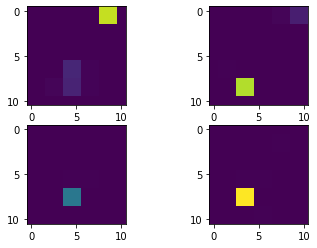

In [191]:
fig, axs = plt.subplots(2, 2)
for i in (0, 1):
    for j in (0, 1):
        axs[j, i].imshow(xx_super[:, :, 2*i + j].cpu(), vmin=0, vmax=1)

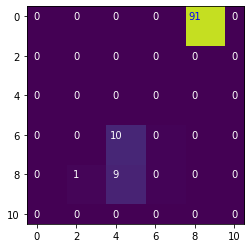

In [192]:
plot_annotated_img(xx_super[:,:, 0])

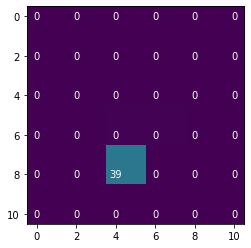

In [193]:
plot_annotated_img(xx_super[:,:, 1])

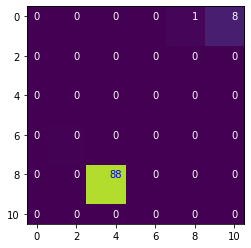

In [194]:
plot_annotated_img(xx_super[:,:, 2])

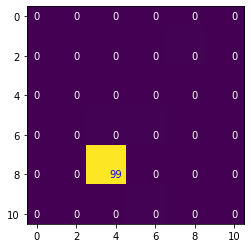

In [195]:
plot_annotated_img(xx_super[:,:, 3])

New estimate of number of objects in area

In [101]:
xx.sum()

tensor(2.1703, device='cuda:0')

This estimate makes sense, as there could be more than two objects that aren't easily detected.

In [106]:
2 + 0.04 * 25 * 0.2

2.2

Each individual tiling estimate underestimates the number of objects (though some of that is a boundary issue since the top-right object goes out of range).

In [255]:
reduce(log_probs_all.exp(), "nth ntw d -> d", "sum")

tensor([1.5529, 0.7751, 1.9657, 1.0799], device='cuda:0')

The third set of disjoint tiles only happens to be close to the true because it under-estimates the object to the upper-right and over-estimates the object to the bottom-left.

In [257]:
log_probs_all.exp().sum() / 4

tensor(1.3434, device='cuda:0')

# Inference of non-overlapping subtiles

We can recover a non-overlapping marginal over subtiles by utilizing the estimated mean and covariance associated with each tile. Given that a tile generated an object, we can calculate which subtile it fell in using a normal CDF.

In [107]:
loc_means = torch.stack([t["loc_mean"][0, :, :, 0, :] for t in tile_maps], dim = -1)
loc_sds = torch.stack([t["loc_sd"][0, :, :, 0, :] for t in tile_maps], dim = -1)

In [108]:
loc_means.shape

torch.Size([5, 5, 2, 4])

In [109]:
loc_sds.shape

torch.Size([5, 5, 2, 4])

In [110]:
loc_means_h = loc_means[:, :, 0]
loc_means_w = loc_means[:, :, 1]
loc_sds_h = loc_sds[:, :, 0]
loc_sds_w = loc_sds[:, :, 1]
dist_h = torch.distributions.Normal(loc_means_h, loc_sds_h)
dist_w = torch.distributions.Normal(loc_means_w, loc_sds_w)

device = loc_means_h.device
start = torch.tensor(0.0, device = device)
mid = torch.tensor(0.5, device = device)
end = torch.tensor(1.0, device = device)

prob_h_top = (dist_h.cdf(mid) - dist_h.cdf(start)) / (dist_h.cdf(end) - dist_h.cdf(start))
prob_h_bot = 1 - prob_h_top
prob_h = torch.stack((prob_h_top, prob_h_bot), dim=-1)
prob_h = rearrange(prob_h, "nl nth ntw sh -> nl nth ntw sh 1", sh=2)

prob_w_left = (dist_w.cdf(mid) - dist_w.cdf(start)) / (dist_w.cdf(end) - dist_w.cdf(start)) 
prob_w_right = 1 - prob_w_left
prob_w = torch.stack((prob_w_left, prob_w_right), dim=-1)
prob_w = rearrange(prob_w, "nl nth ntw sw -> nl nth ntw 1 sw", sw=2)

probs_in_tile = prob_h * prob_w

In [111]:
probs_in_tile.shape

torch.Size([5, 5, 4, 2, 2])

In [112]:
tile_samples

tensor([[[[False, False, False, False],
          [False, False, False, False],
          [False, False, False, False],
          [False, False, False, False],
          [ True, False, False, False]],

         [[False, False, False, False],
          [False, False, False, False],
          [False, False, False, False],
          [False, False, False, False],
          [False, False, False, False]],

         [[False, False, False, False],
          [False, False, False, False],
          [False, False, False, False],
          [False, False, False, False],
          [False, False, False, False]],

         [[False, False, False, False],
          [False, False, False, False],
          [False, False, False, False],
          [False, False, False, False],
          [False, False, False, False]],

         [[False, False, False, False],
          [False, False,  True, False],
          [False, False, False, False],
          [False, False, False, False],
          [False, False, False, 

In [1]:
tiles_dbl = repeat(tile_samples, "ns h w d -> ns h w d h2 w2",h2=2, w2=2)

NameError: name 'repeat' is not defined

In [ ]:
tiles_dbl.shape

In [2]:
probs_in_subtiles = tiles_dbl * probs_in_tile.unsqueeze(0)

NameError: name 'tiles_dbl' is not defined

In [116]:
probs_in_subtiles.shape

torch.Size([10000, 5, 5, 4, 2, 2])

In [117]:
probs_subtiles = torch.zeros(xx_dbl.shape[0] + 1, xx_dbl.shape[1] + 1, device=probs_in_subtiles.device)

p2 = reduce(probs_in_subtiles, "ns nth ntw nl h2 w2 -> (nth h2) (ntw w2) nl", "mean")

probs_subtiles[:-1, :-1] += p2[:, :, 0]
probs_subtiles[1:, :-1] += p2[:, :, 1]
probs_subtiles[:-1, 1:] += p2[:, :, 2]
probs_subtiles[1:, 1:] += p2[:, :, 3]

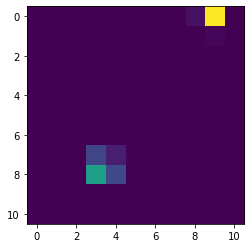

In [118]:
plt.imshow(probs_subtiles.cpu())

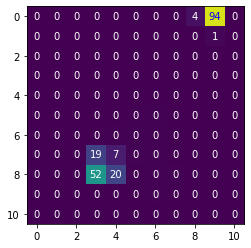

In [160]:
plot_annotated_img(probs_subtiles.cpu(), every_other_tile=False)

In [119]:
probs_subtiles[7:9, 3:5]

tensor([[0.1949, 0.0793],
        [0.5266, 0.2091]], device='cuda:0')

In [120]:
probs_subtiles[7:9, 3:5].sum()

tensor(1.0100, device='cuda:0')

In [121]:
probs_subtiles.sum()

tensor(2.1703, device='cuda:0')

In [123]:
probs_subtiles[:2, -3:]

tensor([[4.1152e-02, 9.4057e-01, 1.5143e-08],
        [1.2859e-03, 1.8262e-02, 5.9900e-05]], device='cuda:0')